In [10]:
import MDAnalysis as mda

In [11]:
traj0 = "/global/cfs/cdirs/m4248/xiaoxusr/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_8_1/results_restart/lammps.298K.prod.lammpsdump"

In [12]:
traj1 = "./lammps.298K.prod.lammpsdump"

In [14]:
# u = mda.Universe("./lammps.data", traj0)

/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/ele_machine_clone/lib/python3.10/site-packages/MDAnalysis/coordinates/LAMMPS.py:667: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data['time'] = step_num * ts.dt


In [7]:
u = mda.Universe("./lammps.data", traj0, traj1)

/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/ele_machine_clone/lib/python3.10/site-packages/MDAnalysis/coordinates/LAMMPS.py:667: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data['time'] = step_num * ts.dt
/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/ele_machine_clone/lib/python3.10/site-packages/MDAnalysis/coordinates/base.py:728: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt


In [8]:
len(u.trajectory)

50002

In [16]:
Na_uw = u.select_atoms("type 11")

In [20]:
center_C_uw = u.select_atoms("type 1 and (charge -0.2137 to -0.2136)")

In [21]:
center_C_uw, Na_uw

(<AtomGroup with 64 atoms>, <AtomGroup with 256 atoms>)

In [12]:
COM_list = []
for ts in u.trajectory[::100]:
    COM_list.append(u.atoms.center_of_mass())

In [13]:
COM_list

[array([29.37252823, 33.18257131, 25.27748906]),
 array([29.37252812, 33.18257115, 25.27748873]),
 array([29.3725277 , 33.18257153, 25.2774887 ]),
 array([29.37252766, 33.18257161, 25.27748896]),
 array([29.37252737, 33.18257129, 25.27748864]),
 array([29.37252822, 33.18257124, 25.27748861]),
 array([29.37252804, 33.18257158, 25.27748827]),
 array([29.37252768, 33.18257098, 25.27748874]),
 array([29.37252766, 33.18257137, 25.27748934]),
 array([29.37252737, 33.18257132, 25.27748865]),
 array([29.3725277 , 33.18257166, 25.27748896]),
 array([29.37252777, 33.18257158, 25.2774884 ]),
 array([29.37252787, 33.18257149, 25.27748895]),
 array([29.37252756, 33.18257128, 25.27748928]),
 array([29.37252766, 33.18257166, 25.27748836]),
 array([29.37252786, 33.18257106, 25.27748849]),
 array([29.37252791, 33.18257127, 25.27748854]),
 array([29.37252816, 33.18257184, 25.27748843]),
 array([29.37252795, 33.18257145, 25.27748889]),
 array([29.3725277 , 33.18257109, 25.27748852]),
 array([29.37252752,

In [14]:
import matplotlib.pyplot as plt

In [15]:
def remove_system_com(ts):
    # subtract current system COM so COM is pinned (translation only)
    ts.positions -= u.atoms.center_of_mass()
    return ts

In [16]:
u.trajectory.add_transformations(remove_system_com)

### Treat 4N as a whole

### Transport Property

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import MDAnalysis as mda
from scipy import stats
from tqdm import tqdm
import MDAnalysis.analysis.msd as msd
from scipy.stats import linregress


#### Define functions to compute transport coefficients

##### Functions for ion correlation analysis

### 1. MSD method -- Einstein Formula, no ion correlation, for dilute solution

https://docs.mdanalysis.org/2.8.0/documentation_pages/analysis/msd.html

In [18]:
center_C = u.select_atoms("type 1 and (charge -0.2137 to -0.2136)")

In [19]:
center_C.charges[0], len(center_C)


(-0.2136950045824051, 64)

In [20]:
center_C_selection = "type 1 and (charge -0.2137 to -0.2136)"

In [21]:
MSD_Na = msd.EinsteinMSD(u, select='type 11', msd_type='xyz', fft=True)
MSD_center_C = msd.EinsteinMSD(u, select=center_C_selection, msd_type='xyz', fft=True)

In [24]:
MSD_Na.run(step=10)
MSD_center_C.run(step=10)


100%|██████████| 64/64 [00:00<00:00, 612.33it/s]


In [25]:
msd_Na =  MSD_Na.results.timeseries
msd_center_C =  MSD_center_C.results.timeseries


In [26]:
MSD_Na.n_frames

5001

Fitted slope (should be ~1 for diffusion): 0.1344
Intercept: -0.9870
R²: 0.9990


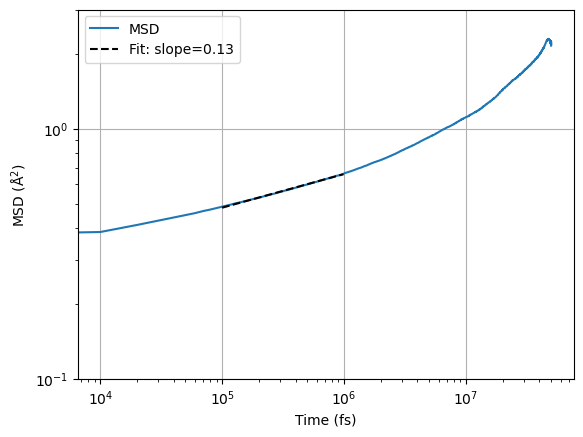

Na+ self diffusivity is 2.927615816217902e-13 m2/s.


In [27]:
nframes = len(msd_Na)
timestep = 10000 # this needs to be the actual time between frames
lagtimes = np.arange(nframes)*timestep # make the lag-time axis

start = int(1e5/timestep)
end = int(1e6/timestep)
# Slice the fitting region
log_t = np.log10(lagtimes[start:end])
log_msd = np.log10(np.abs(msd_Na[start:end]))

# Linear regression in log-log space
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_msd)

# Print results
print(f"Fitted slope (should be ~1 for diffusion): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")

# Plot original data
plt.plot(lagtimes, np.abs(msd_Na), label='MSD')
# Plot fitted line (converted from log-log to linear space)
fit_line = 10**intercept * lagtimes[start:end]**slope
plt.plot(lagtimes[start:end], fit_line, 'k--', label=f'Fit: slope={slope:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (fs)')
plt.ylabel('MSD ($\mathrm{\AA}^2$)')
plt.ylim(0.1, 3)
plt.grid(which='major')
plt.legend()
plt.savefig("Na_MSD_linear.png",bbox_inches="tight")
plt.show()


# calculate self-diffusion coefficient
from scipy.stats import linregress
linear_model = linregress(lagtimes[start:end], msd_Na[start:end])
slope = linear_model.slope
error = linear_model.stderr
# dim_fac is 3 as we computed a 3D msd with 'xyz'
D_Na = slope * 1/(2*MSD_Na.dim_fac)*1e-5
print(f"Na+ self diffusivity is {D_Na} m2/s.")


Fitted slope (should be ~1 for diffusion): 0.1178
Intercept: -0.9717
R²: 0.9992


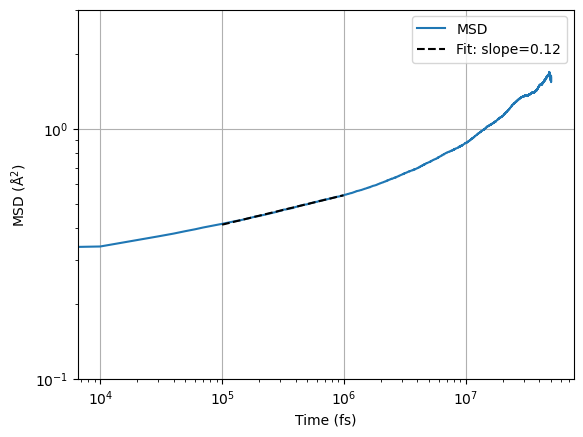

Tetrameric anion (4-) self diffusivity is 2.131055439144046e-13 m2/s.


In [28]:
nframes = len(msd_center_C)
timestep = 10000 # this needs to be the actual time between frames
lagtimes = np.arange(nframes)*timestep # make the lag-time axis

start = int(1e5/timestep)
end = int(1e6/timestep)
# Slice the fitting region
log_t = np.log10(lagtimes[start:end])
log_msd = np.log10(np.abs(msd_center_C[start:end]))

# Linear regression in log-log space
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_msd)

# Print results
print(f"Fitted slope (should be ~1 for diffusion): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")

# Plot origicenter_Cl data
plt.plot(lagtimes, np.abs(msd_center_C), label='MSD')
# Plot fitted line (converted from log-log to linear space)
fit_line = 10**intercept * lagtimes[start:end]**slope
plt.plot(lagtimes[start:end], fit_line, 'k--', label=f'Fit: slope={slope:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time (fs)')
plt.ylabel('MSD ($\mathrm{\AA}^2$)')
plt.ylim(0.1, 3)
plt.grid(which='major')
plt.legend()
plt.savefig("Tetrameric_Anion_MSD_linear.png",bbox_inches="tight")
plt.show()

# calculate self-diffusion coefficient
from scipy.stats import linregress
linear_model = linregress(lagtimes[start:end], msd_center_C[start:end])
slope = linear_model.slope
error = linear_model.stderr
# dim_fac is 3 as we computed a 3D msd with 'xyz'
D_center_C= slope * 1/(2*MSD_center_C.dim_fac)*1e-5
print(f"Tetrameric anion (4-) self diffusivity is {D_center_C} m2/s.")

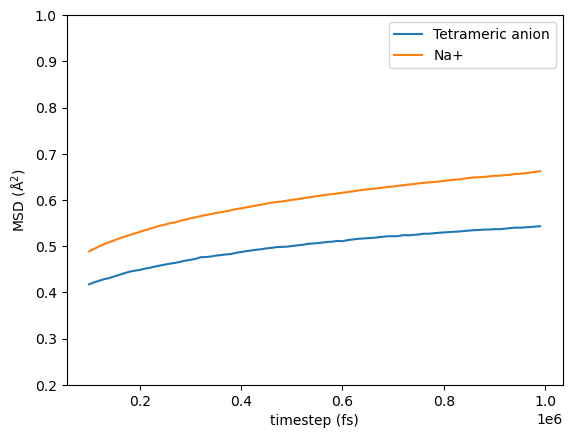

In [29]:
fig = plt.figure()
ax = plt.axes()
# plot the actual msd
ax.plot(lagtimes[start:end], msd_center_C[start:end], ls="-", label="Tetrameric anion")
ax.plot(lagtimes[start:end], msd_Na[start:end], ls="-", label="Na+")
plt.ylabel("MSD ($\mathrm{\AA}^2$)")
plt.xlabel("timestep (fs)")
plt.ylim(0.2,1)
plt.legend()
plt.savefig("MSD_linear_region.png", bbox_inches="tight")
plt.show()

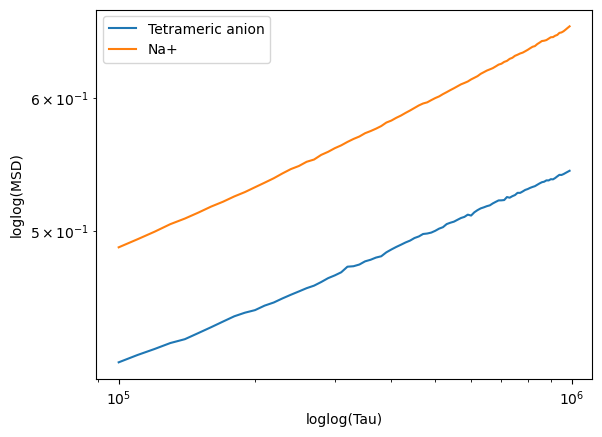

In [30]:
plt.loglog(lagtimes[start:end], msd_center_C[start:end], ls="-", label="Tetrameric anion")
plt.loglog(lagtimes[start:end], msd_Na[start:end], ls="-", label="Na+")
plt.ylabel("loglog(MSD)")
plt.xlabel("loglog(Tau)")
plt.legend()
plt.show()


#### save MSD data

In [31]:
msd_data = {"lagtimes(fs)":lagtimes, 
            r"MSD_Na$^+$ (Å²)":msd_Na, 
            r"MSD_Tetrameric$^4-$ (Å²)": msd_center_C}

In [32]:
import pandas as pd
msd_df = pd.DataFrame(msd_data)

In [33]:
msd_df.to_csv("MSD_data_8glyme.csv")

#### Self-diffusivity data

In [34]:
from scipy.stats import linregress
# sliding through [1e4, 9.1e5] [2e4, 9.2e5]... [1e5, 1e6]
end0 = int(91e4/timestep)
end1 = int(101e4/timestep)
D_Na_list = []

for end in range(end0, end1):
    linear_model = linregress(lagtimes[end-90: end],msd_Na[end-90: end])
    slope = linear_model.slope
    error = linear_model.stderr
    # dim_fac is 3 as we computed a 3D msd with 'xyz'
    D_Na = slope * 1/(2*MSD_Na.dim_fac)*1e-5
    D_Na_list.append(D_Na)

In [35]:
from scipy.stats import linregress
end0 = int(91e4/timestep)
end1 = int(101e4/timestep)
D_center_C_list = []
for end in range(end0, end1):
    linear_model = linregress(lagtimes[end-90: end],msd_center_C[end-90:end])
    slope = linear_model.slope
    error = linear_model.stderr
    # dim_fac is 3 as we computed a 3D msd with 'xyz'
    D_center_C = slope * 1/(2*MSD_center_C.dim_fac)*1e-5
    D_center_C_list.append(D_center_C)

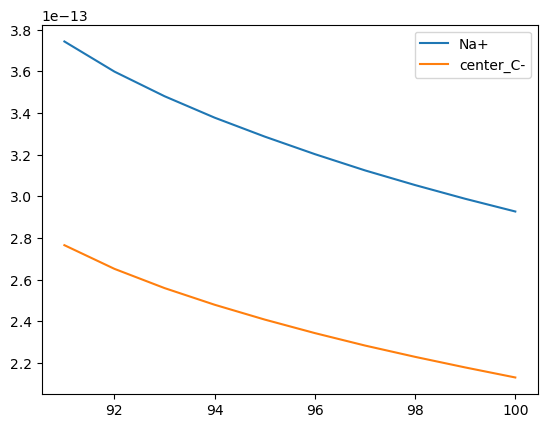

In [80]:
plt.plot(range(end0, end1), D_Na_list, label="Na+")
plt.plot(range(end0, end1), D_center_C_list, label="center_C-")
# plt.ylim(0,3e-13)
plt.legend()


In [81]:
start = int(1e5/timestep)
end = int(1e6/timestep)
linear_model = linregress(lagtimes[start:end], msd_Na[start:end])
slope = linear_model.slope
error = linear_model.stderr
# dim_fac is 3 as we computed a 3D msd with 'xyz'
D_Na = slope * 1/(2*MSD_Na.dim_fac)*1e-5

In [82]:
linear_model = linregress(lagtimes[start:end], msd_center_C[start:end])
slope = linear_model.slope
error = linear_model.stderr
# dim_fac is 3 as we computed a 3D msd with 'xyz'
D_center_C = slope * 1/(2*MSD_center_C.dim_fac)*1e-5

In [83]:
D_Na, D_center_C

(2.927615816217902e-13, 2.131055439144046e-13)

In [84]:
D_Na_mean, D_Na_error = np.mean(D_Na_list), np.std(D_Na_list)
D_Na_mean, D_Na_error

(3.27861028339662e-13, 2.5619839323355088e-14)

In [85]:
D_center_C_mean, D_center_C_error = np.mean(D_center_C_list), np.std(D_center_C_list)
D_center_C_mean, D_center_C_error

(2.4035622875391464e-13, 1.9898708256305084e-14)

In [42]:
# self diffusivity calculated from different windows
self_diffusivity_data = {"lagtimes(fs)":range(end0*timestep,end1*timestep,timestep), 
            r"D_Na$^+$ (m$^2$/s)":D_Na_list, 
            r"D_Tetrameric$^4-$ (m$^2$/s)": D_center_C_list}

In [ ]:
self_diffusivity_df = pd.DataFrame(self_diffusivity_data)

In [ ]:
self_diffusivity_df.to_csv("self_diffusivity_8glyme.csv")

In [4]:
import pandas as pd

In [7]:
self_diffusivity_df = pd.read_csv("self_diffusivity_8glyme.csv")
lagtimes = self_diffusivity_df["lagtimes(fs)"]
D_Na_list = self_diffusivity_df[r"D_Na$^+$ (m$^2$/s)"]
D_center_C_list = self_diffusivity_df[r"D_Tetrameric$^4-$ (m$^2$/s)"]

$$
\sigma_{NE} = \frac{e^2}{k_B T V} \sum_i z_i^2 N_i D_i
$$
Where:

- $\sigma $: ionic conductivity (S/m)  
- $ e $: elementary charge \( (1.602 \times 10^{-19} \, \text{C}) \)  
- $ k_B $: Boltzmann constant \( (1.381 \times 10^{-23} \, \text{J/K}) \)  
- $ T $: temperature (K)  
- $ V $: system volume (m³)  
- $ z_i $: charge valence of species \( i \)  
- $ N_i $: number of ions of species \( i \)  
- $ D_i $: self-diffusivity of species \( i \) (m²/s)

---

In [15]:
e2c = 1.60217662e-19
kbT = 4.11*1e-21
volume = u.dimensions[0]*u.dimensions[1]*u.dimensions[2]

In [ ]:
conductivity_NE_list = []

In [38]:
timestep = 10000
end0 = int(91e4/timestep)
end1 = int(101e4/timestep)

In [ ]:
# self diffusivity calculated from different windows
transport_NE_data = {"lagtimes(fs)":range(end0*timestep,end1*timestep,timestep), 
                         r"D_Na$^+$ (m$^2$/s)":D_Na_list,
                         r"D_Tetrameric$^4-$ (m$^2$/s)": D_center_C_list,
                         "conductivity_NE (S/m)": conductivity_NE_list,
                        }

In [40]:
transport_NE_df = pd.DataFrame(transport_NE_data)

In [42]:
transport_NE_df.to_csv("transport_NE_8glyme.csv")

In [46]:
conductivity_NE = e2c**2/kbT/(volume*1e-30) * (len(Na_uw)*1**2*D_Na + len(center_C)*(-4)**2*D_center_C)
print(f"{conductivity_NE=}S/m")

conductivity_NE=0.009525046672233955S/m
